## Importing Packages

In [91]:
import pandas as pd
import numpy as np
import polars as pl
import glob

from tvDatafeed import TvDatafeed, Interval
import pandas_ta as ta
from backtesting import Backtest, Strategy, set_bokeh_output

import matplotlib.pyplot as plt

import os
import traceback
from datetime import date

In [92]:
set_bokeh_output(notebook = True)

## Creating the Dataset

### Logging into TVFeed

In [93]:
tv = TvDatafeed()

you are using nologin method, data you access may be limited


### Downloading NIFTY 500 (index list downloaded from NSE website on 16th November)

In [94]:
data_nifty500 = pl.read_csv('ind_nifty500list.csv')

symbols_nifty500 = data_nifty500['Symbol'].to_list()

# Correcting the mismatch in the usage of - instead of _ in the datasets
symbols_nifty500 = [s.replace("-", "_") for s in symbols_nifty500]

# Removing a dummy entry
symbols_nifty500.remove('DUMMYSKFIN')

print(f'Total stocks: {len(symbols_nifty500)}')

Total stocks: 501


In [95]:
failed = []

# Performing this operation only when the final master file does not exist
if not os.path.exists("Data/Processed/Prices_all.parquet"):
    for symbol in symbols_nifty500:
        
        # Downloading 5000 bars (approx 20 years). Will filter as per requirement
        try:
            df = tv.get_hist(symbol = symbol,
                             exchange = 'NSE',
                             interval = Interval.in_daily,
                             n_bars = 5000)

            # Using Parquet files instead of pandas to speed up computation
            df.to_parquet(f"data/raw/prices/{symbol}.parquet")

        except Exception as e:
            failed.append(symbol)


    # TVFeed fails to download the data sometimes. This while loop ensures that all 501 stocks are downloaded properly
    while len(failed) != 0:

        for symbol in failed[:]:

            try:
                df = tv.get_hist(symbol = symbol,
                                 exchange = 'NSE',
                                 interval = Interval.in_daily,
                                 n_bars = 5000)

                df.to_parquet(f"data/raw/prices/{symbol}.parquet")
                failed.remove(symbol)

            except:
                pass

    print("\nFailed cases were run repeatedly until success. Data is complete.")

else:
    print("Skipping as data file already exists")

Skipping as data file already exists


### Downloading NIFTY 50 data for benchmarking and regime filtering

In [96]:
if not os.path.exists("Data/Raw/NIFTY_50.parquet"):
    index_df = tv.get_hist(symbol = 'NIFTY', exchange = 'NSE', interval = Interval.in_daily, n_bars = 5000)
    index_df.to_parquet("Data/Raw/NIFTY_50.parquet")

else:
    index_df = pd.read_parquet("Data/Raw/NIFTY_50.parquet")
    print("Skipping as NIFTY 50 data already exists")

Skipping as NIFTY 50 data already exists


### Merging individual stock data files into a single master file

In [97]:
raw_directory = "Data/Raw/Prices"
output_file = "Data/Processed/Prices_all.parquet"

def merge_parquet_files():

    # Performing this operation only when the final master file does not exist
    if os.path.exists(output_file):
        print("Skipping to avoid overwrite as merged data file already exists")
        return

    files = glob.glob(os.path.join(raw_directory, "*.parquet"))

    if len(files) == 0:
        print("No parquet files found in data/raw/prices/")
        return

    dfs = []

    for file in files:
        symbol = os.path.basename(file).replace(".parquet", "")
        df = (pl.read_parquet(file).with_columns([pl.lit(symbol).alias("symbol")]))
        df = df.rename({"datetime": "date"})
        dfs.append(df)

    final_df = pl.concat(dfs, how = "vertical")
    final_df = final_df.sort(["symbol", "date"])
    final_df.write_parquet(output_file)

    print(f"Master file created: {output_file}")
    print(f"\nRows: {final_df.height}, Columns: {final_df.width}")


if __name__ == "__main__":
    merge_parquet_files()

Skipping to avoid overwrite as merged data file already exists


## Loading the Dataset

#### Loading and filtering to start the analysis from 2018

In [98]:
# Starting the analysis from 2018
analysis_start_date = pd.Timestamp(2011, 1, 1)

# Train date starts from 1 January, 2014
train_start_date = pd.Timestamp(2012, 1, 1)

# Test date starts from 1 January, 2020
test_start_date = pd.Timestamp(2020, 1, 1)

# Filtering to remove all date before 2018 and sorting by symbol and price to maintain chronology
df = (pl.read_parquet("Data/Processed/Prices_all.parquet")
      .filter(pl.col("date") >= analysis_start_date)
      .sort(["symbol", "date"]))

# Capitalizing the columns to maintain backfeed.py's naming convention
df = df.rename({col: col.capitalize() for col in df.columns})

print("The dimensions of the dataframe:", df.shape)
df.head

The dimensions of the dataframe: (1402156, 7)


<bound method DataFrame.head of shape: (1_402_156, 7)
┌───────────┬─────────┬─────────┬─────────┬──────────┬────────────┬─────────────────────┐
│ Symbol    ┆ Open    ┆ High    ┆ Low     ┆ Close    ┆ Volume     ┆ Date                │
│ ---       ┆ ---     ┆ ---     ┆ ---     ┆ ---      ┆ ---        ┆ ---                 │
│ str       ┆ f64     ┆ f64     ┆ f64     ┆ f64      ┆ f64        ┆ datetime[ns]        │
╞═══════════╪═════════╪═════════╪═════════╪══════════╪════════════╪═════════════════════╡
│ 360ONE    ┆ 302.5   ┆ 317.625 ┆ 302.5   ┆ 317.625  ┆ 7.10986e6  ┆ 2019-09-19 09:15:00 │
│ 360ONE    ┆ 332.25  ┆ 333.5   ┆ 332.25  ┆ 333.5    ┆ 2.760648e6 ┆ 2019-09-20 09:15:00 │
│ 360ONE    ┆ 350.175 ┆ 350.175 ┆ 350.175 ┆ 350.175  ┆ 34096.0    ┆ 2019-09-23 09:15:00 │
│ 360ONE    ┆ 367.675 ┆ 367.675 ┆ 367.675 ┆ 367.675  ┆ 2.496652e6 ┆ 2019-09-24 09:15:00 │
│ 360ONE    ┆ 386.05  ┆ 386.05  ┆ 349.3   ┆ 351.2375 ┆ 530580.0   ┆ 2019-09-25 09:15:00 │
│ …         ┆ …       ┆ …       ┆ …       ┆ … 

In [99]:
# Doing the same modifications to the NIFTY Index dataset as well
index_df = index_df.reset_index()

# Capitalizing the columns to maintain backfeed.py's naming convention
index_df.columns = [c.capitalize() for c in index_df.columns]

# Converting datatime to date for later calculations
index_df = index_df.rename(columns = {"Datetime": "Date"})
index_df["Date"] = pd.to_datetime(index_df["Date"])

# Filtering the date to start from 2018
index_df = index_df[index_df["Date"] >= analysis_start_date]

# Sorting to ensure that the chronology is maintained
index_df = index_df.sort_values("Date")

print("The dimensions of the dataframe:", index_df.shape)
index_df.head()

The dimensions of the dataframe: (3686, 7)


,Date,Symbol,Open,High,Low,Close,Volume
1314,2011-01-03 09:15:00,NSE:NIFTY,6177.4502,6178.5498,6147.2002,6157.6001,96029000.0
1315,2011-01-04 09:15:00,NSE:NIFTY,6172.7500,6181.0498,6124.3999,6146.3501,181728002.0
1316,2011-01-05 09:15:00,NSE:NIFTY,6141.3501,6141.3501,6062.3501,6079.7998,139613995.0
1317,2011-01-06 09:15:00,NSE:NIFTY,6107.0000,6116.1499,6022.2998,6048.2500,152339005.0
1318,2011-01-07 09:15:00,NSE:NIFTY,6030.8999,6051.2002,5883.6001,5904.6001,171808997.0


### Checking how many stocks out of the 501 were listed from 2018

In [100]:
count = (df.filter(pl.col("Date") == test_start_date)
         .select(pl.col("Symbol").n_unique())
         .item())

print("Listed on 1 January, 2018:", count, "stocks")

Listed on 1 January, 2018: 0 stocks


## Setting up the functions to compute indicators

### Setting up the technical indicators as functions for reuse

#### 1) Moving Average Convergence Divergence (MACD)

In [101]:
def MACD(close, fast, slow, signal):
    MACD = ta.macd(close = close, fast = fast, slow = slow, signal = signal)
    return MACD[f"MACD_{fast}_{slow}_{signal}"]

#### 2) MACD Signal

In [102]:
def MACD_Signal(close, fast, slow, signal):
    MACD_signal = ta.macd(close = close, fast = fast, slow = slow, signal = signal)
    return MACD_signal[f"MACDs_{fast}_{slow}_{signal}"]

#### 3) Volume-weighted Average Price (VWAP)

In [103]:
def VWAP(high, low, close, volume, length):
    VWAP_20 = ta.vwap(high = high, low = low, close = close, volume = volume, length = length)
    return VWAP_20

#### 4) Rate of Change (ROC)

In [104]:
def ROC(close, length):
    ROC = ta.roc(close = close, length = length)
    return ROC

#### 5) Relative Strength Index (RSI)

In [105]:
def RSI(close, length):
    RSI = ta.rsi(close = close, length = length)
    return RSI

#### 6) Average Directional Movement Index (ADX)

In [106]:
def ADX(high, low, close, length):
    ADX = ta.adx(high = high, low = low, close = close, length = length)
    return ADX[f"ADX_{length}"]

#### 7) Moving Average (MA)

In [107]:
def MA(variable, length):
    ma = ta.sma(close = variable, length = length)
    return pd.to_numeric(ma, errors = "coerce")

#### 8) Average True Range (ATR)

In [108]:
def ATR(high, low, close, length):
    ATR = ta.atr(high = high, low = low, close = close, length = length)
    return ATR

#### 9) Volatility

In [109]:
def Volatility(close, length):
    Volatility = ta.stdev(close = close, length = length)
    return Volatility

#### 10) Trend Noise Ratio

In [110]:
def Trend_noise_ratio(high, low, close):
    ATR_14 = ATR(high = high, low = low, close = close, length = 14)
    MA_50 = MA(variable = close, length = 50)
    MA_200 = MA(variable = close, length = 200)

    difference = (MA_50 - MA_200).abs()
    difference = difference.replace(0, np.nan)

    Trend_Noise_Ratio = ATR_14/ difference
    Trend_Noise_Ratio = Trend_Noise_Ratio.replace([np.inf, -np.inf], np.nan)

    return Trend_Noise_Ratio

#### 11) Gap

In [111]:
def Gap(open, close):
    GAP = open - close.shift(1).abs()/ close.shift(1)
    return GAP

### 12) Breadth

In [112]:
def breadth(df_dict):
    symbols = list(df_dict.keys())
    dates = df_dict[symbols[0]].index

    ma_dict = {}
    
    for symbol in symbols:
        df = df_dict[symbol].copy()
        df["MA-Price_50"] = MA(df["Close"], length = 50)
        df = df.dropna(subset = ["MA-Price_50"]) 
        ma_dict[symbol] = df
    

    breadth_list = []

    for date in dates:
        count = 0
        total = 0

        for symbol in symbols:
            df = ma_dict[symbol]

            if date not in df.index:
                continue

            row = df.loc[date]

            MA_50 = row["MA-Price_50"]
            close = row["Close"]

            total += 1
            if close > MA_50:
                count += 1

        breadth_list.append(count / total if total > 0 else np.nan)

    return pd.DataFrame({"Breadth": breadth_list}, index = dates)

## Computing the technical indicators

In [113]:
def compute_indicators(df):
    
    df = df.copy()
    # if len(df) < 200:
    #     return None

    df = df.apply(pd.to_numeric, errors="coerce")  # convert None → NaN
    df = df.dropna(subset=["Open", "High", "Low", "Close", "Volume"])  # drop pre-IPO rows

    # Basic OHLCV values
    o = df["Open"]
    h = df["High"]
    l  = df["Low"]
    c = df["Close"]
    v = df["Volume"]

    # Computing the technical indicators
    df["ATR"]   = ATR(high = h, low = l, close = c, length = 14)
    df["ADX"]   = ADX(high = h, low = l, close = c, length = 14)
    df["ROC"] = ROC(close = c, length = 20)
    df["MACD"]  = MACD(close = c, fast = 12, slow = 26, signal = 9)
    df["MACD_signal"]  = MACD_Signal(close = c, fast = 12, slow = 26, signal = 9)
    df["VWAP"]  = VWAP(high = h, low = l , close = c, volume = v, length = 5)
    df["RSI"]  = RSI(close = c, length = 14)
    df["MA-Volume_10"]  = MA(variable = v, length = 10)
    df["Volatility"] = Volatility(close = c, length = 20)
    df["Trend_noise_ratio"] = Trend_noise_ratio(high = h, low = l, close = c)
    df["Gap"] = Gap(open = o, close = c)

    # Moving averages of Price needed for scoring
    df["MA-Price_20"]  = MA(variable = c, length = 20)
    df["MA-Price_50"]  = MA(variable = c, length = 50)
    df["MA-Price_100"] = MA(variable = c, length = 100)
    df["MA-Price_200"] = MA(variable = c, length = 200)

    return df

## Setting up the Strategies

### Setting up the strategy - Medium Strategy

In [114]:
class Medium_Strategy(Strategy):
    # Initializing a direction filter that allows strategies to take only long or short positions based on the market regime
    direction = "both"

    # Hyperparameters in the strategy for fine tuning
    tp_ATR = 3
    sl_ATR = 2

    sl_percentage = 0.075
    risk_per_trade = 0.05



    def init(self):
        # Setting up the High, Low and Close values as attributes
        h = pd.Series(self.data.High, index = self.data.index)
        l = pd.Series(self.data.Low, index = self.data.index)
        c = pd.Series(self.data.Close, index = self.data.index)

        # Computing the required indicators and setting them up as attributes
        self.macd = self.I(MACD, close = c, fast = 12, slow = 26, signal = 9)
        self.roc  = self.I(ROC, close = c, length = 14)
        self.adx  = self.I(ADX, high = h, low = l, close = c, length = 14)
        self.atr  = self.I(ATR, high = h, low = l, close = c, length = 14)

        # Initializing Entry Price and Stop Loss as attributes
        self.entry_price = None
        self.current_stop_loss  = None




    # Sizing short/ long position based on risk tolerance
    def calc_position_size(self, price):
        equity = self.equity
        risk_capital = equity * self.risk_per_trade
        per_share_risk = price * self.sl_percentage

        size = int(risk_capital // per_share_risk)
        return max(size, 1)
    



    def next(self):
        # Taking indicators for the relevant time period for signal generation/ validation/ filtering
        price_now = self.data.Close[-1]
        atr_now = self.atr[-1]
        macd_now = self.macd[-1]
        roc_now = self.roc[-1]
        adx_now = self.adx[-1]


        # Exit Logic - When MACD trend reverses or when price exceeds (3 * ATR) for Profit Booking and (2 * ATR) range for Stop Loss
        if self.position:

            # MACD trend reverses - Exit Position as it goes against the strategy's logic
            exit = (self.position.is_long and macd_now < 0) or \
                   (self.position.is_short and macd_now > 0)

            
            # Price > (3 * ATR) - Book profits and exit (similarly for short position)
            exit_tp = (self.position.is_long and price_now >= self.entry_price + (self.tp_ATR * atr_now)) or \
                      (self.position.is_short and price_now <= self.entry_price - (self.tp_ATR * atr_now))

            # Price < (2 * ATR) - Stop Loss (similarly for short position)
            if self.position.is_long:
                new_stop_loss = price_now - (self.sl_ATR * atr_now)
                
                if new_stop_loss > self.current_stop_loss:
                    self.current_stop_loss = new_stop_loss

                exit_sl = (price_now <= self.current_stop_loss)

            else:
                new_stop_loss = price_now + (self.sl_ATR * atr_now)

                if new_stop_loss < self.current_stop_loss:
                    self.current_stop_loss = new_stop_loss

                exit_sl = (price_now >= self.current_stop_loss)

            # Exit position if trend reverses, profit booking opportunity or stop loss requirement
            if exit or exit_tp or exit_sl:
                self.position.close()
                self.entry_price = None
                self.current_stop_loss  = None

            return


        # Entry Logic:
        # Signal Generation - MACD shows that there is some trend
        # Signal Validation - ROC ensures consistency in the trend
        # Signal Filtering - ADX shows momentum (avoids random noise)
        long_signal = (macd_now > 0 and roc_now > 0 and adx_now > 25)
        short_signal = (macd_now < 0 and roc_now < 0 and adx_now > 25)


        # Sizing the position based on risk
        size = self.calc_position_size(price_now)


        # Force trade type (long/ short) based on market regime
        if self.direction == "long":
            short_signal = False

        if self.direction == "short":
            long_signal = False


        # Enter Long or Short based on above logic
        if long_signal:
            sl = price_now - (self.sl_ATR * atr_now)
            tp = price_now + (self.tp_ATR * atr_now)

            self.buy(sl = sl, tp = tp, size = size)

            self.entry_price = price_now
            self.current_stop_loss  = sl

        elif short_signal:
            sl = price_now + (self.sl_ATR * atr_now)
            tp = price_now - (self.tp_ATR * atr_now)

            self.sell(sl = sl, tp = tp, size = size)

            self.entry_price = price_now
            self.current_stop_loss  = sl
    

print("Medium Strategy class defined")

Medium Strategy class defined


### Setting up the strategy - High Strategy

In [115]:
class High_Strategy(Strategy):
    
    # Initializing a direction filter that allows strategies to take only long or short positions based on the market regime
    direction = "both"

    # Hyperparameters in the strategy for fine tuning
    sl_percentage = 0.10
    risk_per_trade = 0.075

    tp_percentage = 0.10

    vwap_deviation = 0.015
    max_holding_bars = 15

    tp_ATR = 3
    sl_ATR = 2



    def init(self):
        # Setting up the High, Low, Close and Volume values as attributes
        h = pd.Series(self.data.High, index = self.data.index)
        l = pd.Series(self.data.Low, index = self.data.index)
        c = pd.Series(self.data.Close, index = self.data.index)
        v = pd.Series(self.data.Volume, index = self.data.index)

        # Computing the required indicators and setting them up as attributes
        self.vwap = self.I(VWAP, high = h, low = l, close = c, volume = v, length = 20)
        self.rsi  = self.I(RSI, close = c, length = 5)
        self.sma_volume  = self.I(MA, variable = v, length = 20)
        self.adx = self.I(ADX, high = h, low = l, close = c, length = 14)
        self.atr  = self.I(ATR, high = h, low = l, close = c, length = 14)

        # Initializing Entry Price and Stop Loss as attributes
        self.entry_price = None
        self.current_sl  = None

        # Since this strategy comes with considerable risk, restrict the number of days that a position can be open for
        self.bars_in_trade = 0




    # Sizing short/ long position based on risk tolerance
    def calc_position_size(self, price):
        equity = self.equity
        risk_capital = equity * self.risk_per_trade
        per_share_risk = price * self.sl_percentage

        size = int(risk_capital // per_share_risk)
        return max(size, 1)




    def next(self):
        # Taking indicators for the relevant time period for signal generation/ validation/ filtering
        price_now = self.data.Close[-1]
        vwap_now = self.vwap[-1]
        rsi_now = self.rsi[-1]
        atr = self.atr[-1]

        # Increment days with open position by 1
        if self.position:
            self.bars_in_trade += 1

            # Exit Logic 1 - When RSI is no longer indicating oversold/ overbought
            exit = (self.position.is_long and rsi_now > 70) or \
                   (self.position.is_short and rsi_now < 30)

            # Exit Logic 2 - When the maximum days for having an open position is exhausted
            exit_days_exceeded = self.bars_in_trade >= self.max_holding_bars
            
            # Price > (3 * ATR) - Book profits and exit (similarly for short position)
            exit_tp = (self.position.is_long and price_now >= self.entry_price + (self.sl_ATR * atr)) or \
                               (self.position.is_short and price_now <= self.entry_price - (self.tp_ATR * atr))


            # Price < (2 * ATR) - Stop Loss (similarly for short position)
            if self.position.is_long:
                new_sl = price_now - (self.sl_ATR * atr)

                if new_sl > self.current_sl:
                    self.current_sl = new_sl

                exit_sl = price_now <= self.current_sl

            else:
                new_sl = price_now + (self.sl_ATR * atr)

                if new_sl < self.current_sl:
                    self.current_sl = new_sl

                exit_sl = price_now >= self.current_sl
            

            # Exit position if any of the above exit logic conditions are true
            if exit or exit_days_exceeded or exit_tp or exit_sl:
                self.position.close()
                self.bars_in_trade = 0
                self.entry_price = None
                self.current_sl  = None
                
            return


        # Entry Logic:
        # Signal Generation - price < 20-day vwap (with some relaxation) signalling that there is interest picking up in the stock
        # Signal Validation - RSI ensures that the stock is heavily oversold (overbought), creating a mean reversion setup
        long_signal = ((price_now < vwap_now * (1 - self.vwap_deviation)) and 
                       (rsi_now < 20))
        
        short_signal = ((price_now > vwap_now * (1 + self.vwap_deviation)) and 
                       (rsi_now > 80))


        # Sizing the position based on risk
        size = self.calc_position_size(price_now)
        

        # Force trade type (long/ short) based on market regime
        if self.direction == "long":
            short_signal = False

        if self.direction == "short":
            long_signal = False


        # Enter Long or Short based on above logic
        if long_signal:
            sl = price_now * (1 - self.sl_percentage)
            tp = price_now * (1 + self.tp_percentage)

            self.buy(sl = sl, tp = tp, size = size)

            self.entry_price = price_now
            self.current_sl  = sl
            self.bars_in_trade = 0

        elif short_signal:
            sl = price_now * (1 + self.sl_percentage)
            tp = price_now * (1 - self.tp_percentage)

            self.sell(sl = sl, tp = tp, size = size)

            self.entry_price = price_now
            self.current_sl  = sl
            self.bars_in_trade = 0
    

print("High Strategy class defined")

High Strategy class defined


## Stock selection

### Filtering the universe to avoid poor performers in indicators like turnover, price, volume, and volatility

In [116]:
def filter_stocks(df_dict):
    filtered_stocks = []

    for symbol, df in df_dict.items():
        # Computing the turnover - value traded
        df["Turnover"] = df["Close"] * df["Volume"]

        # Filtering only liquid stocks - 20-day average trade value over rupees 10 crore
        if df["Turnover"].rolling(20).mean().iloc[-1] < 10_00_00_000:
            continue

        # Removing stocks with a low price (generally volatile stocks) - reject if price is less than 10
        if df["Close"].rolling(20).mean().iloc[-1] < 10:
            continue

        # Filtering only liquid stocks (some stocks might have a high turnover due to high prices) - 
        # reject if 20-day average volume less than 50 thousand 
        if df["Volume"].rolling(20).mean().iloc[-1] < 50_000:
            continue

        # Removing highly volatile stocks - 20-day standard deviation of returns greater than 6%
        if df["Close"].pct_change().rolling(20).std().iloc[-1] > 0.06:
            continue
        
        # Retain only those stocks that pass all these filters
        filtered_stocks.append(symbol)

    return filtered_stocks

### Using XGBoost to pick the best stocks

In [ ]:
# #---------This part is WIP---------

# df_XGBoost = df.to_pandas().copy()
# df_XGBoost = df_XGBoost[df_XGBoost['Date'] < test_start_date]

# df_XGBoost_dict = {}

# for symbol, group in df_XGBoost.groupby("Symbol"):
#     group = group.sort_values("Date").copy()
#     group = group.set_index("Date")[["Open", "High", "Low", "Close", "Volume"]]
#     df_XGBoost_dict[symbol] = group

# df_train_all_stocks_indicators = []

# for symbol, df_symbol in df_XGBoost_dict.items():
#     df_indicators = compute_indicators(df_symbol)
#     df_indicators["Symbol"] = symbol
#     df_train_all_stocks_indicators.append(df_indicators)

# df_train_all_stocks_indicators = pd.concat(df_train_all_stocks_indicators).reset_index()

### Selecting stocks from the filtered universe - Medium Strategy

In [117]:
#---------This part is WIP---------

def medium_select_stocks(df_dict, lookback):
    rows = []

    for symbol, df in df_dict.items():
        try:
            df_ind = compute_indicators(df)
            if df_ind is None or len(df_ind) < lookback:
                continue

            data = df_ind.tail(lookback).copy()

            # Trend Structure
            Up_trend   = ((data["MA-Price_20"] > data["MA-Price_50"]) & (data["MA-Price_50"] > data["MA-Price_100"])).mean()
            Down_trend = ((data["MA-Price_20"] < data["MA-Price_50"]) & (data["MA-Price_50"] < data["MA-Price_100"])).mean()

            Slope_50  = data["MA-Price_50"].diff().mean()
            Slope_200 = data["MA-Price_200"].diff().mean()

            # Momentum Quality
            ROC_up   = (data["ROC"] > 0).mean()
            ROC_down = (data["ROC"] < 0).mean()

            MACD_up    = (data["MACD"] > 0).mean()
            MACD_down  = (data["MACD"] < 0).mean()

            # Smoothness: how often MACD > its signal line
            MACD_trend_quality = (data["MACD"] > data["MACD_signal"]).mean()

            # Trend Strength (ADX)
            ADX_strength = (data["ADX"] > 20).mean()

            # Noise (lower is better)
            Noise = (data["ATR"] / (data["Close"].diff().abs() + 1e-9)).mean()

            # Breakout Quality
            Breakout_strength = ((data["Close"] > data["Close"].rolling(50).max().shift(1)).mean())

            # Liquidity
            Turnover = (data["Close"] * data["Volume"]).rolling(20).mean().iloc[-1]

            rows.append({"Symbol": symbol,
                         
                         "Up_trend": Up_trend,
                         "ROC_up": ROC_up,
                         "MACD_up": MACD_up,
                         
                         "Down_trend": Down_trend,
                         "ROC_down": ROC_down,
                         "MACD_down": MACD_down,
                         
                         "Slope_50": Slope_50,
                         "Slope_200": Slope_200,
                         "ADX_strength": ADX_strength,
                         "MACD_trend_quality": MACD_trend_quality,
                         "Noise": Noise,
                         "Breakout": Breakout_strength,
                         "Turnover": Turnover})

        except Exception as e:
            print(f"Error in {symbol}: {e}")

    df = pd.DataFrame(rows)
    if df.empty:
        return []

    # Z-score everything except symbol
    for col in df.columns:
        if col != "Symbol":
            df[col + "_z"] = (df[col] - df[col].mean()) / (df[col].std() + 1e-9)

    # LONG SCORE
    df["Long_score"] = (0.35 * df["Up_trend_z"] +
                        0.25 * df["ROC_up_z"] +
                        0.25 * df["MACD_up_z"] +
                        0.15 * df["Slope_50_z"] +
                        0.10 * df["Breakout_z"] +
                        0.10 * df["ADX_strength_z"] -
                        0.20 * df["Noise_z"] +
                        0.10 * df["Turnover_z"])

    # SHORT SCORE
    df["Short_score"] = (0.35 * df["Down_trend_z"] +
                         0.25 * df["ROC_down_z"] +
                         0.25 * df["MACD_down_z"] +
                         0.15 * df["Slope_50_z"] +
                         0.10 * df["ADX_strength_z"] -
                         0.20 * df["Noise_z"] +
                         0.10 * df["Turnover_z"])

    df['Score']= df[["Long_score", "Short_score"]].max(axis = 1)
    df["Direction"] = np.where(df["Long_score"] >= df["Short_score"], "long", "short")

    
    scores = df.sort_values("Score", ascending = False)
    selected_stocks = scores[:20]

    return list(zip(selected_stocks["Symbol"], selected_stocks["Direction"]))

### Selecting stocks from the filtered universe - High Strategy

In [119]:
#---------This part is WIP---------

def high_select_stocks(df_dict, lookback):
    rows = []

    for symbol, df in df_dict.items():
        try:
            df_ind = compute_indicators(df)
            if df_ind is None or len(df_ind) < 60:
                continue

            data = df_ind.tail(10).copy()

            # VWAP tests
            VWAP_up_2d = ((data["VWAP"].iloc[-1] > data["Close"].iloc[-1]) and
                          (data["VWAP"].iloc[-2] > data["Close"].iloc[-2]))

            VWAP_down_2d = ((data["VWAP"].iloc[-1] < data["Close"].iloc[-1]) and 
                            (data["VWAP"].iloc[-2] < data["Close"].iloc[-2]))

            # Volume
            Vol_ratio = data["Volume"].iloc[-1] / (data["MA-Volume_10"].iloc[-1] + 1e-9)

            # RSI
            RSI_now = data["RSI"].iloc[-1]
            RSI_up = (RSI_now > data["RSI"].iloc[-2] > data["RSI"].iloc[-3])
            RSI_down = (RSI_now < data["RSI"].iloc[-2] < data["RSI"].iloc[-3])

            # Long Score
            long_score = ((1.0 if VWAP_up_2d else 0) +
                          (1.0 if (RSI_now < 60 and RSI_up) else 0) +
                          (1.0 if Vol_ratio > 1.2 else 0))

            # Short Score
            short_score = ((1.0 if VWAP_down_2d else 0) +
                           (1.0 if (RSI_now > 40 and RSI_down) else 0) +
                           (1.0 if Vol_ratio < 0.8 else 0) )

            # Pick best direction
            score = max(long_score, short_score)
            direction = "long" if long_score >= short_score else "short"

            # Save row
            rows.append({"Symbol": symbol,
                         "Score": score,
                         "Direction": direction})

        except Exception as e:
            print(f"Error in {symbol}: {e}")
            continue

    df = pd.DataFrame(rows)
    if df.empty:
        return []

    # top 20 with direction
    df_sorted = df.sort_values("Score", ascending = False).head(20)
    return list(zip(df_sorted["Symbol"], df_sorted["Direction"]))

## Market Regime Filter

#### Computing the technical indicators of the market

In [120]:
def compute_regime(index_df):
    # Basic HLV values for NIFTY 50 index
    high = index_df['High']
    low = index_df['Low']
    close = index_df['Close']

    # Computing the technical indicators for NIFTY 50 index
    index_df['MA-Price_20'] = MA(variable = close, length = 20)
    index_df['MA-Price_50'] = MA(variable = close, length = 50)
    index_df['MA-Price_60'] = MA(variable = close, length = 60)
    index_df['MA-Price_200'] = MA(variable = close, length = 200)

    index_df['ADX_14'] = ADX(high = high, low = low, close = close, length = 14)
    index_df['ATR_14'] = ATR(high = high, low = low, close = close, length = 14)
    
    index_df["Regime"] = (index_df["Close"]/ index_df["Close"].shift(20)) - 1

    return index_df

In [121]:
# Calling the function to compute the technical indicators
index_df = compute_regime(index_df)

#### Market regime filter - Medium Strategy

In [122]:
def medium_market_regime(index_df, date):

    if index_df.index.name != 'Date':
        index_df["Date"] = pd.to_datetime(index_df["Date"])
        index_df.set_index('Date', inplace = True)

    # If date values do not match, do not allow any trades as there cannot be a regime filter
    if date not in index_df.index:
        return "none"
    
    row = index_df.loc[date]

    Price = row["Close"]
    MA_60 = row["MA-Price_60"]
    ADX = row["ADX_14"]

    # If MA or ADX indicators are none (beginning of the dataset), do not allow any trades as there cannot be a regime filter
    if pd.isna(MA_60) or pd.isna(ADX):
        return "none"


    # If price is trending upwards and there is some momentum in NIFTY 50, the signals are most likely not random noise - go long
    if (Price > MA_60) and (ADX > 20):
        return "long"

    # If price is trending downwards and there is some momentum in NIFTY 50, the signals are most likely not random noise - go short
    if (Price < MA_60) and (ADX > 20):
        return "short"
    
    return "none"

#### Market Regime Filter - High Strategy

In [123]:
def high_market_regime(index_df, breadth_df, date):

    # If date values do not match, do not allow any trades as there cannot be a regime filter
    if date not in index_df.index:
        return "none"
    
    row_index = index_df.loc[date]
    row_breadth = breadth_df.loc[date]

    MA_50 = row_index["MA-Price_50"]
    MA_200 = row_index["MA-Price_200"]
    Close = row_index["Close"]
    ATR_14 = row_index["ATR_14"]
    
    Breadth = row_breadth["Breadth"] 

    # If MA or ATR indicators are none (beginning of the dataset), do not allow any trades as there cannot be a regime filter
    if pd.isna(MA_50) or pd.isna(MA_200) or pd.isna(ATR_14):
        return "none"
    
    Trend_up = MA_50 > MA_200
    Trend_down = MA_50 < MA_200

    Low_vol = (ATR_14 / Close) < 0.03
    High_vol = (ATR_14 / Close) > 0.04

    Strong_breadth = Breadth > 0.65
    Weak_breadth   = Breadth < 0.35

    # If price is trending upwards for the stock and 65% of NIFTY 50 stocks, the signals are most likely not random noise - go long
    if Trend_up and Low_vol and Strong_breadth:
        return "long"

    # If price is trending downwards for the stock and 65% of NIFTY 50 stocks, the signals are most likely not random noise - go short
    if Trend_down and High_vol and Weak_breadth:
        return "short"

    return "none"

## Backtesting

### Setting up the trade as a function for reuse - Medium Strategy

In [124]:
def Backtest_Medium_Strategy(df_backtest, train_start_date, test_start_date, train):
    
    if train is True:
        # Filtering to include only training days if it is a training run
        df_backtest = df_backtest[(df_backtest['Date'] >= train_start_date) & 
                                  (df_backtest['Date'] < test_start_date)]
        
    else:
        # Filtering to include only test days if it is a test run
        df_backtest = df_backtest[df_backtest['Date'] >= test_start_date]


    trading_dates = sorted(df_backtest["Date"].unique())

    pointer_start = train_start_date if train else test_start_date
    date_pointer = next(i for i, d in enumerate(trading_dates) if d >= pointer_start)

    # Since this is a trend following, momentum driven strategy, having an open position for a few weeks is expected
    # New stocks will always hop onto the trend
    #Therefore, every 45 days all open positions are liquidated and new stocks are chosen based on the selection method
    window = 45

    # Lookback window is needed as some of our filters use MA_200 for comparison
    lookback = 270

    # Arbitrary initial cash amount
    cash = 1_00_00_000

    # The value of the portfolio
    portfolio_equity_curve = []

    df_by_symbol = {symbol: g.sort_values("Date") for symbol, g in df_backtest.groupby("Symbol")}


    while True:
        # Exit the loop if there aren't enough days for a full window
        if date_pointer + window >= len(trading_dates):
            break

        # Test window applicable in this iteration
        test_start_idx = date_pointer
        test_end_idx   = date_pointer + window
        window_dates = trading_dates[test_start_idx : test_end_idx]

        # Cutoff date for lookback is the day before the test window starts
        cutoff_index = max(test_start_idx - 1, 0)
        cutoff_date  = trading_dates[cutoff_index]

        # Previous lookback days ended at the cutoff date
        start_idx = max(0, cutoff_index - (lookback - 1))
        lookback_dates = trading_dates[start_idx : cutoff_index + 1]

        # Build the lookback dataset with the lookback dates
        df_lookback = df_backtest[df_backtest["Date"].isin(lookback_dates)].copy()

        # Builind a dictionary of dataframes with the keys being the stock name and the values being the lookback
        df_dict = {}

        for symbol, group in df_lookback.groupby("Symbol"):
            group = group.sort_values("Date").copy()
            group = group.set_index("Date")[["Open", "High", "Low", "Close", "Volume"]]
            df_dict[symbol] = group

        df_dict = {s: df for s, df in df_dict.items() if len(df) >= lookback}

        # Fiter the dictionary to include only the filtered stocks
        filtered_stocks = filter_stocks(df_dict)
        df_dict = {symbol: df_dict[symbol] for symbol in filtered_stocks}

        # Select top 20 stocks and their direction (short/ long) from the list of filtered stocks for trading
        selected_stocks = medium_select_stocks(df_dict, lookback)    


        # Asessing the market regime to ensure that we are making trades in the correct direction
        regime = medium_market_regime(index_df, cutoff_date)

        # If there is no signal from the market, dont make any trades to avoid jumping on a trend after the trend is over
        if regime == "none":
            print(f"Market regime suggests no trade for the window: {trading_dates[test_start_idx].date()} - {trading_dates[test_end_idx].date()}. Carrying cash forward")
            portfolio_equity_curve.append((cutoff_date, cash))
            date_pointer += window
            continue

        selected_post_regime_filtering = []
        
        # Make long or short trades only based on the market regime filter
        for symbol, direction in selected_stocks:

            if regime == "long" and direction == "long":
                selected_post_regime_filtering.append((symbol, direction))
                
            if regime == "short" and direction == "short":
                selected_post_regime_filtering.append((symbol, direction))

        # If no stock survives after regime filtering, do not make any trades
        if len(selected_post_regime_filtering) == 0:
            print(f"No stocks selected post regime filtering for the window: {trading_dates[test_start_idx].date()} - {trading_dates[test_end_idx].date()}. Carrying cash forward")
            portfolio_equity_curve.append((cutoff_date, cash))
            date_pointer += window
            continue


        future_exists = any(df_by_symbol[s]["Date"].isin(window_dates).sum() > 0 for s, _ in selected_post_regime_filtering)
        
        if not future_exists:
            print(f"No future data available for window : {window_dates[0].date()} - {window_dates[-1].date()}. Carrying cash forward.")
            portfolio_equity_curve.append((cutoff_date, cash))
            date_pointer += window
            continue


        # Run backtest for each selected stock post regime filtering over the next window (backtest.py does not allow multiple stocks)
        window_results = {}

        for stock, direction in selected_post_regime_filtering:
            Medium_Strategy.allowed_direction = direction

            df_selected_stock = df_by_symbol[stock]

            history_dates = df_selected_stock["Date"].isin(lookback_dates)
            future_dates  = df_selected_stock["Date"].isin(window_dates)

            # No test data and therefore skip entirely
            if future_dates.sum() == 0:
                continue

            # Creating the dataset with the lookback window and test window
            df_bt_run = df_selected_stock[history_dates | future_dates].copy()
            df_bt_run = df_bt_run.set_index("Date")[["Open", "High", "Low", "Close", "Volume"]]

            try:
                # Running the backtest for the medium strategy (cash split equally)
                bt = Backtest(df_bt_run,
                            Medium_Strategy,
                            cash = cash / len(selected_post_regime_filtering),
                            exclusive_orders = True,
                            finalize_trades = True)
                
                stats = bt.run(direction = direction)
                window_results[stock] = stats

            except Exception as e:
                print("\nERROR inside Backtest for:", stock)
                traceback.print_exc()
                raise SystemExit

        # If backtest fails, notify the window, skip the window and move ahead
        if not window_results:
            print(f"All backtests failed in the window: {trading_dates[test_start_idx].date()} - {trading_dates[test_end_idx].date()}. Carrying cash forward.")
            portfolio_equity_curve.append((cutoff_date, cash))
            date_pointer += window
            continue
        
        # Calculating the returns made from the trade
        returns = {s: r["Return [%]"] / 100 for s, r in window_results.items()}
        n = len(returns)
        portfolio_return = sum(ret * (1/n) for ret in returns.values())
        cash = cash * (1 + portfolio_return)

        portfolio_equity_curve.append((cutoff_date, cash))

        date_pointer += window

    return portfolio_equity_curve

### Setting up the strategy as a function for reuse - High Strategy

In [125]:
def Backtest_High_Strategy(df_backtest, train_start_date, test_start_date, train):
    
    if train is True:
        # Filtering to include only training days if it is a training run
        df_backtest = df_backtest[(df_backtest['Date'] >= train_start_date) & 
                                  (df_backtest['Date'] < test_start_date)]
        
    else:
        # Filtering to include only test days if it is a test run
        df_backtest = df_backtest[df_backtest['Date'] >= test_start_date]


    trading_dates = sorted(df_backtest["Date"].unique())

    pointer_start = train_start_date if train else test_start_date
    date_pointer = next(i for i, d in enumerate(trading_dates) if d >= pointer_start)

    window = 15
    lookback = 270
    cash = 1_00_00_000

    portfolio_equity_curve = []

    df_by_symbol = {symbol: g.sort_values("Date") for symbol, g in df_backtest.groupby("Symbol")}


    while True:

        if date_pointer + window >= len(trading_dates):
            break

        # test window: the NEXT `window` days
        test_start_idx = date_pointer
        test_end_idx   = date_pointer + window

        window_dates = trading_dates[test_start_idx : test_end_idx]

        # cutoff is the day BEFORE the test window starts
        cutoff_index = max(test_start_idx - 1, 0)
        cutoff_date  = trading_dates[cutoff_index]

        # lookback: last `lookback` days ending at cutoff_date
        start_idx = max(0, cutoff_index - (lookback - 1))
        lookback_dates = trading_dates[start_idx : cutoff_index + 1]


        # Build lookback OHLCV per symbol
        df_lookback = df_backtest[df_backtest["Date"].isin(lookback_dates)].copy()

        df_dict = {}

        for symbol, group in df_lookback.groupby("Symbol"):
            group = group.sort_values("Date").copy()
            group = group.set_index("Date")[["Open", "High", "Low", "Close", "Volume"]]
            df_dict[symbol] = group

        # Filter & rank
        df_dict = {s: df for s, df in df_dict.items() if len(df) >= lookback}
        filtered_stocks = filter_stocks(df_dict)
        df_dict = {symbol: df_dict[symbol] for symbol in filtered_stocks}

        if not df_dict:
            print(f"No stocks survived factor filters for window: {trading_dates[test_start_idx].date()} - {trading_dates[test_end_idx].date()}. Carrying cash forward.")
            portfolio_equity_curve.append((cutoff_date, cash))
            date_pointer += window
            continue

        breadth_df = breadth(df_dict)
        
        selected_stocks = high_select_stocks(df_dict, lookback)
        
        # Regime Filter
        regime = high_market_regime(index_df, breadth_df, cutoff_date)

        if regime == "none":
            print(f"Market regime suggests no trade for the window: {trading_dates[test_start_idx].date()} - {trading_dates[test_end_idx].date()}. Carrying cash forward")
            portfolio_equity_curve.append((cutoff_date, cash))
            date_pointer += window
            continue

        selected_post_regime_filtering = []
        

        for symbol, direction in selected_stocks:

            if regime == "long" and direction == "long":
                selected_post_regime_filtering.append((symbol, direction))
                
            if regime == "short" and direction == "short":
                selected_post_regime_filtering.append((symbol, direction))

        if len(selected_post_regime_filtering) == 0:
            print(f"No stocks selected post regime filtering for the window: {trading_dates[test_start_idx].date()} - {trading_dates[test_end_idx].date()}. Carrying cash forward")
            portfolio_equity_curve.append((cutoff_date, cash))
            date_pointer += window
            continue


        # Run backtest for each selected stock over the next window
        window_results = {}

        for stock, direction in selected_post_regime_filtering:
            df_selected_stock = df_by_symbol[stock]

            history_dates = df_selected_stock["Date"].isin(lookback_dates)
            future_dates  = df_selected_stock["Date"].isin(window_dates)

            # No test data and therefore skip entirely
            if future_dates.sum() == 0:
                continue

            df_bt_run = df_selected_stock[history_dates | future_dates].copy()
            df_bt_run = df_bt_run.set_index("Date")[["Open", "High", "Low", "Close", "Volume"]]


            # Ensure we actually have test data
            future_mask = df_bt_run.index.isin(window_dates)

            if future_mask.sum() == 0:
                continue

            try:
                bt = Backtest(df_bt_run,
                            High_Strategy,
                            cash = cash / len(selected_post_regime_filtering),
                            exclusive_orders = True,
                            finalize_trades = True)
                
                stats = bt.run(direction = direction)
                window_results[stock] = stats

            except Exception as e:
                print("\nERROR inside Backtest for:", stock)
                traceback.print_exc()
                raise SystemExit

        if not window_results:
            print(f"All backtests failed in the window: {trading_dates[test_start_idx].date()} - {trading_dates[test_end_idx].date()}. Carrying cash forward.")
            portfolio_equity_curve.append((cutoff_date, cash))
            date_pointer += window
            continue

        returns = {s: r["Return [%]"] / 100 for s, r in window_results.items()}
        n = len(returns)
        portfolio_return = sum(ret * (1/n) for ret in returns.values())
        cash = cash * (1 + portfolio_return)

        portfolio_equity_curve.append((cutoff_date, cash))

        date_pointer += window
    
    return portfolio_equity_curve

### Training Results - Medium Strategy

In [126]:
# Converting polaris dateframe into pandas for backtesting
df_backtest = df.to_pandas()

# Keeping only the relevant columns and sorting by date to maintain chronology
df_backtest = df_backtest[["Date", "Symbol", "Open", "High", "Low", "Close", "Volume"]]
df_backtest = df_backtest.sort_values(["Date"])

In [127]:
train_equity_medium = Backtest_Medium_Strategy(df_backtest, train_start_date, test_start_date, train = True)

Market regime suggests no trade for the window: 2012-01-02 - 2012-03-07. Carrying cash forward
No stocks selected post regime filtering for the window: 2012-03-07 - 2012-05-15. Carrying cash forward
No stocks selected post regime filtering for the window: 2012-05-15 - 2012-07-17. Carrying cash forward
No stocks selected post regime filtering for the window: 2012-07-17 - 2012-09-21. Carrying cash forward
No stocks selected post regime filtering for the window: 2012-09-21 - 2012-11-29. Carrying cash forward
Market regime suggests no trade for the window: 2012-11-29 - 2013-02-01. Carrying cash forward


Backtest.run:   0%|          | 0/289 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/289 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/289 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/289 [00:00<?, ?bar/s]

...

Backtest.run:   0%|          | 0/289 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/288 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/288 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/288 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/288 [00:00<?, ?bar/s]

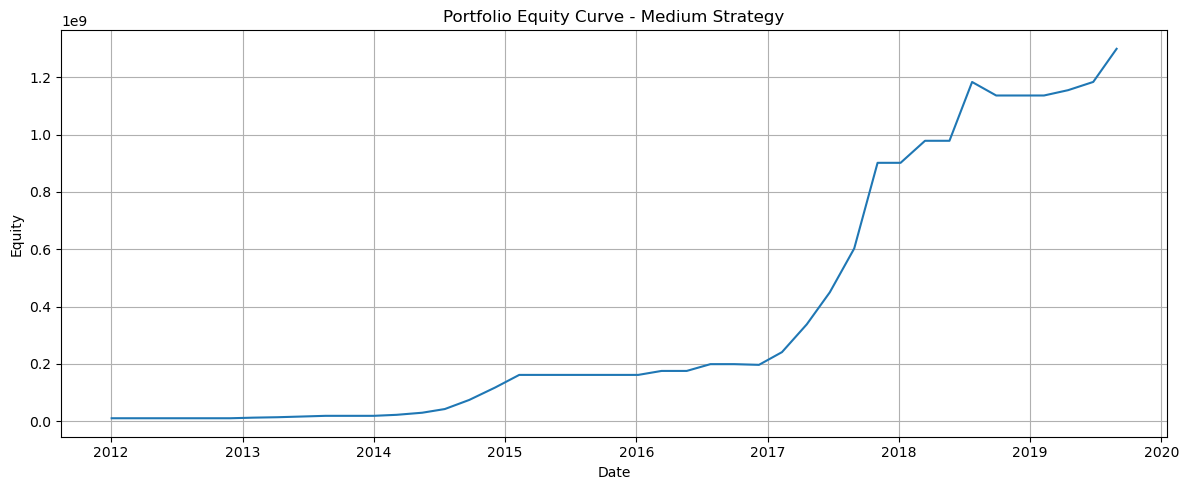

In [128]:
equity_df = pd.DataFrame(train_equity_medium, columns = ["Date", "Equity"])
equity_df = equity_df.sort_values("Date")
equity_df.set_index("Date", inplace = True)

plt.figure(figsize = (12,5))
plt.plot(equity_df.index, equity_df["Equity"])

plt.title("Portfolio Equity Curve - Medium Strategy")
plt.xlabel("Date")
plt.ylabel("Equity")

plt.grid(True)

plt.tight_layout()
plt.show()

In [129]:
start_val = equity_df["Equity"].iloc[0]
end_val   = equity_df["Equity"].iloc[-1]

years = (equity_df.index[-1] - equity_df.index[0]).days / 365
CAGR = round(100 * ((end_val / start_val) ** (1/ years) - 1), 2)

running_max = equity_df["Equity"].cummax()
drawdown = (equity_df["Equity"] - running_max) / running_max
max_dd = drawdown.min()

print(f"CAGR: {CAGR}%")
print(f"Max Drawdown: {round(100 * max_dd, 1)}%")

CAGR: 88.78%
Max Drawdown: -4.0%


### Training Results - High Strategy

In [130]:
train_equity_high = Backtest_High_Strategy(df_backtest, train_start_date, test_start_date, train = True)

No stocks survived factor filters for window: 2012-01-02 - 2012-01-23. Carrying cash forward.
No stocks survived factor filters for window: 2012-01-23 - 2012-02-14. Carrying cash forward.
No stocks survived factor filters for window: 2012-02-14 - 2012-03-07. Carrying cash forward.
No stocks survived factor filters for window: 2012-03-07 - 2012-03-29. Carrying cash forward.
No stocks survived factor filters for window: 2012-03-29 - 2012-04-23. Carrying cash forward.
No stocks survived factor filters for window: 2012-04-23 - 2012-05-15. Carrying cash forward.
No stocks survived factor filters for window: 2012-05-15 - 2012-06-05. Carrying cash forward.
No stocks survived factor filters for window: 2012-06-05 - 2012-06-26. Carrying cash forward.
No stocks survived factor filters for window: 2012-06-26 - 2012-07-17. Carrying cash forward.
No stocks survived factor filters for window: 2012-07-17 - 2012-08-07. Carrying cash forward.
No stocks survived factor filters for window: 2012-08-07 - 2

Backtest.run:   0%|          | 0/265 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/265 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/265 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/265 [00:00<?, ?bar/s]

...

Backtest.run:   0%|          | 0/265 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/265 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/265 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/265 [00:00<?, ?bar/s]

Market regime suggests no trade for the window: 2019-05-14 - 2019-06-04. Carrying cash forward
Market regime suggests no trade for the window: 2019-06-04 - 2019-06-26. Carrying cash forward
Market regime suggests no trade for the window: 2019-06-26 - 2019-07-17. Carrying cash forward
Market regime suggests no trade for the window: 2019-07-17 - 2019-08-07. Carrying cash forward
Market regime suggests no trade for the window: 2019-08-07 - 2019-08-30. Carrying cash forward
Market regime suggests no trade for the window: 2019-08-30 - 2019-09-24. Carrying cash forward
Market regime suggests no trade for the window: 2019-09-24 - 2019-10-17. Carrying cash forward
Market regime suggests no trade for the window: 2019-10-17 - 2019-11-08. Carrying cash forward
No stocks survived factor filters for window: 2019-11-08 - 2019-12-02. Carrying cash forward.
No stocks survived factor filters for window: 2019-12-02 - 2019-12-23. Carrying cash forward.


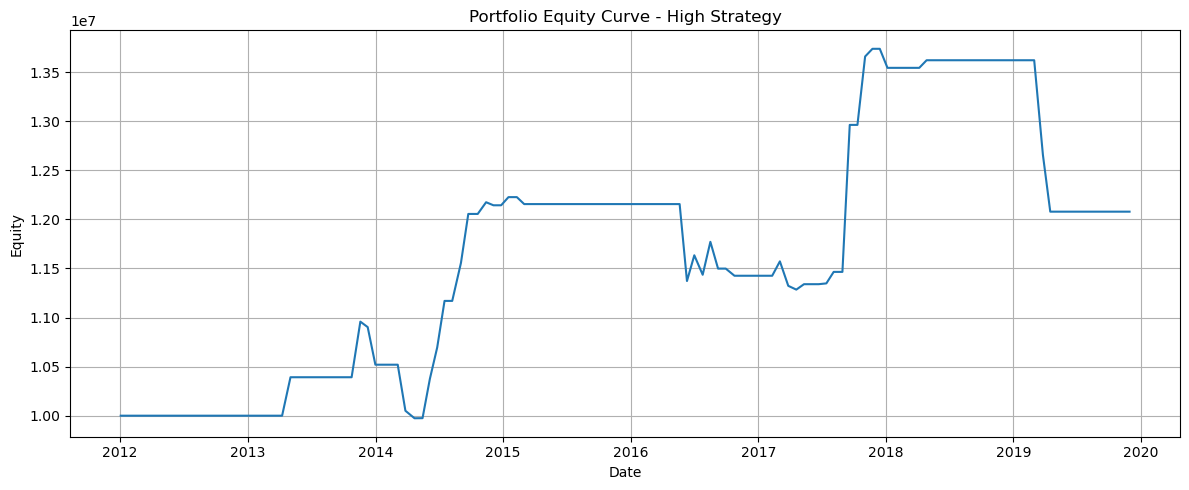

In [131]:
equity_df = pd.DataFrame(train_equity_high, columns = ["Date", "Equity"])
equity_df = equity_df.sort_values("Date")
equity_df.set_index("Date", inplace = True)

plt.figure(figsize = (12,5))
plt.plot(equity_df.index, equity_df["Equity"])

plt.title("Portfolio Equity Curve - High Strategy")
plt.xlabel("Date")
plt.ylabel("Equity")

plt.grid(True)

plt.tight_layout()
plt.show()

In [132]:
start_val = equity_df["Equity"].iloc[0]
end_val   = equity_df["Equity"].iloc[-1]

years = (equity_df.index[-1] - equity_df.index[0]).days / 365
CAGR = round(100 * ((end_val / start_val) ** (1/ years) - 1), 2)

running_max = equity_df["Equity"].cummax()
drawdown = (equity_df["Equity"] - running_max) / running_max
max_dd = drawdown.min()

print(f"CAGR: {CAGR}%")
print(f"Max Drawdown: {round(100 * max_dd, 1)}%")

CAGR: 2.42%
Max Drawdown: -12.1%


### Test Results - High Strategy

In [133]:
test_equity_medium = Backtest_Medium_Strategy(df_backtest, train_start_date, test_start_date, train = False)

Market regime suggests no trade for the window: 2020-01-01 - 2020-03-04. Carrying cash forward
No stocks selected post regime filtering for the window: 2020-03-04 - 2020-05-14. Carrying cash forward
Market regime suggests no trade for the window: 2020-05-14 - 2020-07-17. Carrying cash forward
No stocks selected post regime filtering for the window: 2020-07-17 - 2020-09-18. Carrying cash forward
Market regime suggests no trade for the window: 2020-09-18 - 2020-11-23. Carrying cash forward
No stocks selected post regime filtering for the window: 2020-11-23 - 2021-01-28. Carrying cash forward


Backtest.run:   0%|          | 0/289 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/289 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/289 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/289 [00:00<?, ?bar/s]

...

Backtest.run:   0%|          | 0/289 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/289 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/289 [00:00<?, ?bar/s]

Market regime suggests no trade for the window: 2025-06-09 - 2025-08-11. Carrying cash forward


Backtest.run:   0%|          | 0/289 [00:00<?, ?bar/s]

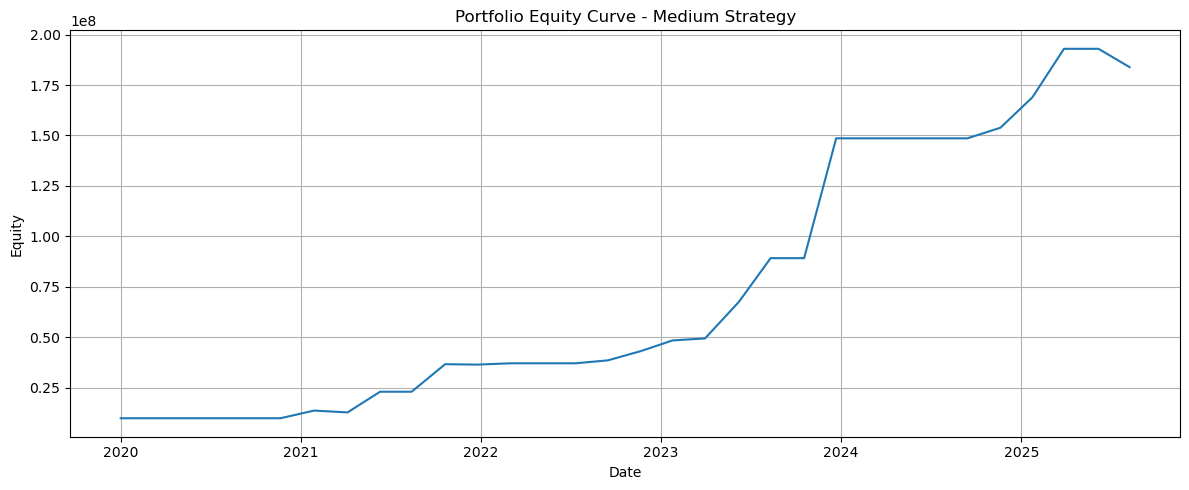

In [134]:
equity_df = pd.DataFrame(test_equity_medium, columns = ["Date", "Equity"])
equity_df = equity_df.sort_values("Date")
equity_df.set_index("Date", inplace = True)

plt.figure(figsize = (12,5))
plt.plot(equity_df.index, equity_df["Equity"])
plt.title("Portfolio Equity Curve - Medium Strategy")
plt.xlabel("Date")
plt.ylabel("Equity")
plt.grid(True)
plt.tight_layout()
plt.show()

In [135]:
start_val = equity_df["Equity"].iloc[0]
end_val   = equity_df["Equity"].iloc[-1]

years = (equity_df.index[-1] - equity_df.index[0]).days / 365
CAGR = round(100 * ((end_val / start_val) ** (1/ years) - 1), 2)

running_max = equity_df["Equity"].cummax()
drawdown = (equity_df["Equity"] - running_max) / running_max
max_dd = drawdown.min()

print(f"CAGR: {CAGR}%")
print(f"Max Drawdown: {round(100 * max_dd, 1)}%")

CAGR: 68.1%
Max Drawdown: -6.6%


In [136]:
test_equity_high = Backtest_High_Strategy(df_backtest, train_start_date, test_start_date, train = False)

No stocks survived factor filters for window: 2020-01-01 - 2020-01-22. Carrying cash forward.
No stocks survived factor filters for window: 2020-01-22 - 2020-02-11. Carrying cash forward.
No stocks survived factor filters for window: 2020-02-11 - 2020-03-04. Carrying cash forward.
No stocks survived factor filters for window: 2020-03-04 - 2020-03-26. Carrying cash forward.
No stocks survived factor filters for window: 2020-03-26 - 2020-04-22. Carrying cash forward.
No stocks survived factor filters for window: 2020-04-22 - 2020-05-14. Carrying cash forward.
No stocks survived factor filters for window: 2020-05-14 - 2020-06-05. Carrying cash forward.
No stocks survived factor filters for window: 2020-06-05 - 2020-06-26. Carrying cash forward.
No stocks survived factor filters for window: 2020-06-26 - 2020-07-17. Carrying cash forward.
No stocks survived factor filters for window: 2020-07-17 - 2020-08-07. Carrying cash forward.
No stocks survived factor filters for window: 2020-08-07 - 2

Backtest.run:   0%|          | 0/265 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/265 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/265 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/265 [00:00<?, ?bar/s]

...

Backtest.run:   0%|          | 0/265 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/265 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/265 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/265 [00:00<?, ?bar/s]

Market regime suggests no trade for the window: 2025-08-11 - 2025-09-03. Carrying cash forward
Market regime suggests no trade for the window: 2025-09-03 - 2025-09-24. Carrying cash forward
Market regime suggests no trade for the window: 2025-09-24 - 2025-10-16. Carrying cash forward
Market regime suggests no trade for the window: 2025-10-16 - 2025-11-10. Carrying cash forward


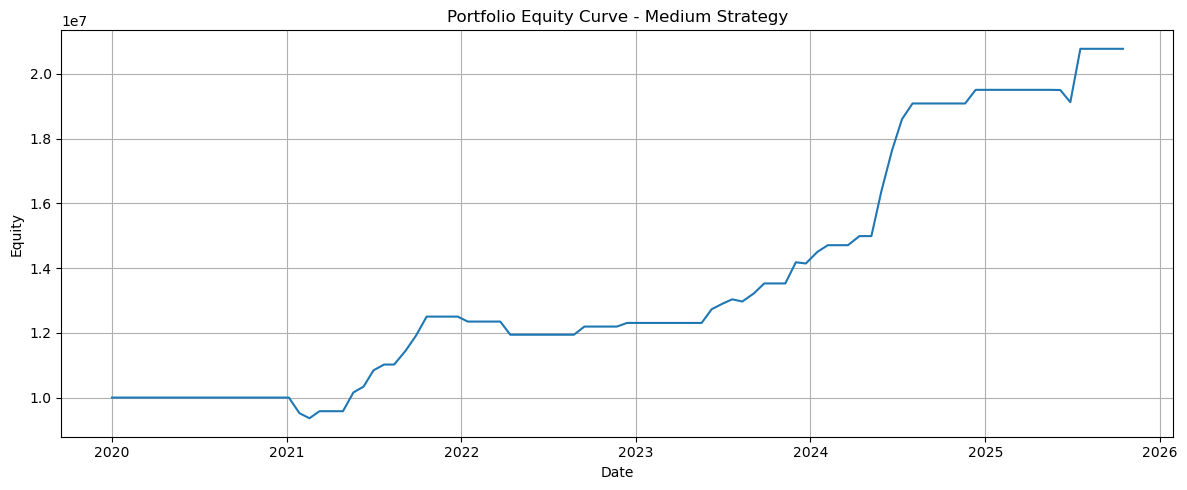

In [137]:
equity_df = pd.DataFrame(test_equity_high, columns = ["Date", "Equity"])
equity_df = equity_df.sort_values("Date")
equity_df.set_index("Date", inplace = True)

plt.figure(figsize = (12,5))
plt.plot(equity_df.index, equity_df["Equity"])
plt.title("Portfolio Equity Curve - Medium Strategy")
plt.xlabel("Date")
plt.ylabel("Equity")
plt.grid(True)
plt.tight_layout()
plt.show()

In [138]:
start_val = equity_df["Equity"].iloc[0]
end_val   = equity_df["Equity"].iloc[-1]

years = (equity_df.index[-1] - equity_df.index[0]).days / 365
CAGR = round(100 * ((end_val / start_val) ** (1/ years) - 1), 2)

running_max = equity_df["Equity"].cummax()
drawdown = (equity_df["Equity"] - running_max) / running_max
max_dd = drawdown.min()

print(f"CAGR: {CAGR}%")
print(f"Max Drawdown: {round(100 * max_dd, 1)}%")

CAGR: 13.46%
Max Drawdown: -6.4%
